# LeetCode #8: String to Integer (atoi)

https://leetcode.com/problems/string-to-integer-atoi/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force (Regex Parsing)** | $O(N)$ | $O(N)$ |
| **Linear Scanning** ★ | $O(N)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force (Regex Parsing)
Use a regular expression like `^\s*[-+]?\d+` to extract the valid portion of the string. Readable, but regex engines have high constant-time overhead and typically copy the matched substring into a new allocation — $O(N)$ extra space.

### Optimal: Linear Scanning ★
Single-pass pointer that follows a strict 4-step sequence: skip whitespace → read optional sign → accumulate digits with overflow guard → stop at first non-digit. No regex, no substring copy.

**Why this is better than Regex:** Same $O(N)$ time, but $O(1)$ space — only a handful of integers are tracked (`i`, `sign`, `result`). The overflow guard mirrors problem 7: check `result > INT_MAX / 10` before multiplying.

**Constraints:**
* `0 <= s.length <= 200`
* `s` consists of English letters, digits, spaces, `'+'`, `'-'`, and `'.'`

## Solutions

### C#

In [ ]:
public class Solution {
    public int MyAtoi(string s) {
        if (string.IsNullOrWhiteSpace(s)) return 0;
        int i = 0, sign = 1, result = 0, n = s.Length;

        // Step 1: skip leading whitespace
        while (i < n && s[i] == ' ') i++;
        if (i == n) return 0;

        // Step 2: capture optional sign
        if (s[i] == '+' || s[i] == '-') {
            sign = (s[i] == '-') ? -1 : 1;
            i++;
        }

        // Step 3: accumulate digits, guarding against 32-bit overflow before each multiply
        while (i < n && char.IsDigit(s[i])) {
            int digit = s[i] - '0';
            if (result > int.MaxValue / 10 || (result == int.MaxValue / 10 && digit > 7)) {
                return sign == 1 ? int.MaxValue : int.MinValue;
            }
            result = result * 10 + digit;
            i++;
        }

        return result * sign;
    }
}

### Python

In [ ]:
class Solution:
    def myAtoi(self, s: str) -> int:
        INT_MAX, INT_MIN = 2**31 - 1, -(2**31)
        i, n = 0, len(s)

        # Step 1: skip leading whitespace
        while i < n and s[i] == ' ':
            i += 1
        if i == n:
            return 0

        # Step 2: capture optional sign
        sign = 1
        if s[i] in ('+', '-'):
            sign = -1 if s[i] == '-' else 1
            i += 1

        # Step 3: accumulate digits, guarding against 32-bit overflow before each multiply
        result = 0
        while i < n and s[i].isdigit():
            digit = int(s[i])
            if result > INT_MAX // 10 or (result == INT_MAX // 10 and digit > 7):
                return INT_MAX if sign == 1 else INT_MIN
            result = result * 10 + digit
            i += 1

        return result * sign

### Go

In [ ]:
import (
    "math"
    "unicode"
)

func myAtoi(s string) int {
    i, n := 0, len(s)

    // Step 1: skip leading whitespace
    for i < n && s[i] == ' ' {
        i++
    }
    if i == n {
        return 0
    }

    // Step 2: capture optional sign
    sign := 1
    if s[i] == '+' || s[i] == '-' {
        if s[i] == '-' {
            sign = -1
        }
        i++
    }

    // Step 3: accumulate digits, guarding against 32-bit overflow before each multiply
    result := 0
    for i < n && unicode.IsDigit(rune(s[i])) {
        digit := int(s[i] - '0')
        if result > math.MaxInt32/10 || (result == math.MaxInt32/10 && digit > 7) {
            if sign == 1 {
                return math.MaxInt32
            }
            return math.MinInt32
        }
        result = result*10 + digit
        i++
    }

    return result * sign
}

### Rust

In [ ]:
impl Solution {
    pub fn my_atoi(s: String) -> i32 {
        let bytes = s.as_bytes();
        let n = bytes.len();
        let mut i = 0;

        // Step 1: skip leading whitespace
        while i < n && bytes[i] == b' ' {
            i += 1;
        }
        if i == n {
            return 0;
        }

        // Step 2: capture optional sign
        let sign: i32 = if bytes[i] == b'-' {
            i += 1; -1
        } else {
            if bytes[i] == b'+' { i += 1; }
            1
        };

        // Step 3: accumulate digits, guarding against 32-bit overflow before each multiply
        let mut result: i32 = 0;
        while i < n && bytes[i].is_ascii_digit() {
            let digit = (bytes[i] - b'0') as i32;
            if result > i32::MAX / 10 || (result == i32::MAX / 10 && digit > 7) {
                return if sign == 1 { i32::MAX } else { i32::MIN };
            }
            result = result * 10 + digit;
            i += 1;
        }

        result * sign
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `s = "42"`  
No whitespace, no sign — the pointer enters the digit phase immediately. Accumulates: result=4, then result=42. The overflow check never fires since 42 is trivially small.  
**Result:** `42`

### 2. Slightly Complex (Leading Spaces + Negative Sign)
**Input:** `s = "   -42"`  
Phase 1 skips 3 spaces (pointer moves 0→3). Phase 2 reads `'-'` and sets sign=-1 (pointer moves 3→4). Phase 3 accumulates 4 and 2. Final: `42 × -1`.  
**Result:** `-42`

### 3. Edge Case: Time Factor (Non-Digit Start)
**Input:** `s = "words and 987"`  
Phase 1 finds no leading spaces. Phase 2 finds no sign. Phase 3's `while IsDigit` fails immediately at `'w'`. The digits "987" later in the string are never reached — O(1) effective work.  
**Result:** `0`

### 4. Edge Case: Space Factor (Exact INT_MAX)
**Input:** `s = "2147483647"`  
Ten digit iterations. The last digit is 7, and the check `result == INT_MAX/10 && digit > 7` evaluates `7 > 7 = false` — so it passes, and 2147483647 is returned directly, not clamped. Only `int result` and `int i` are ever allocated — $O(1)$ space.  
**Result:** `2147483647`

### 5. Almost-Impossible but Plausible: Underflow Clamping
**Input:** `s = "-91283472332"`  
Sign is set to -1. Digit accumulation proceeds until iteration 10 where result = 912,834,723 — already greater than INT_MAX/10 = 214,748,364. The check fires and returns INT_MIN (-2,147,483,648) because sign == -1. The last two digits never processed.  
**Result:** `-2147483648` (INT_MIN, clamped)

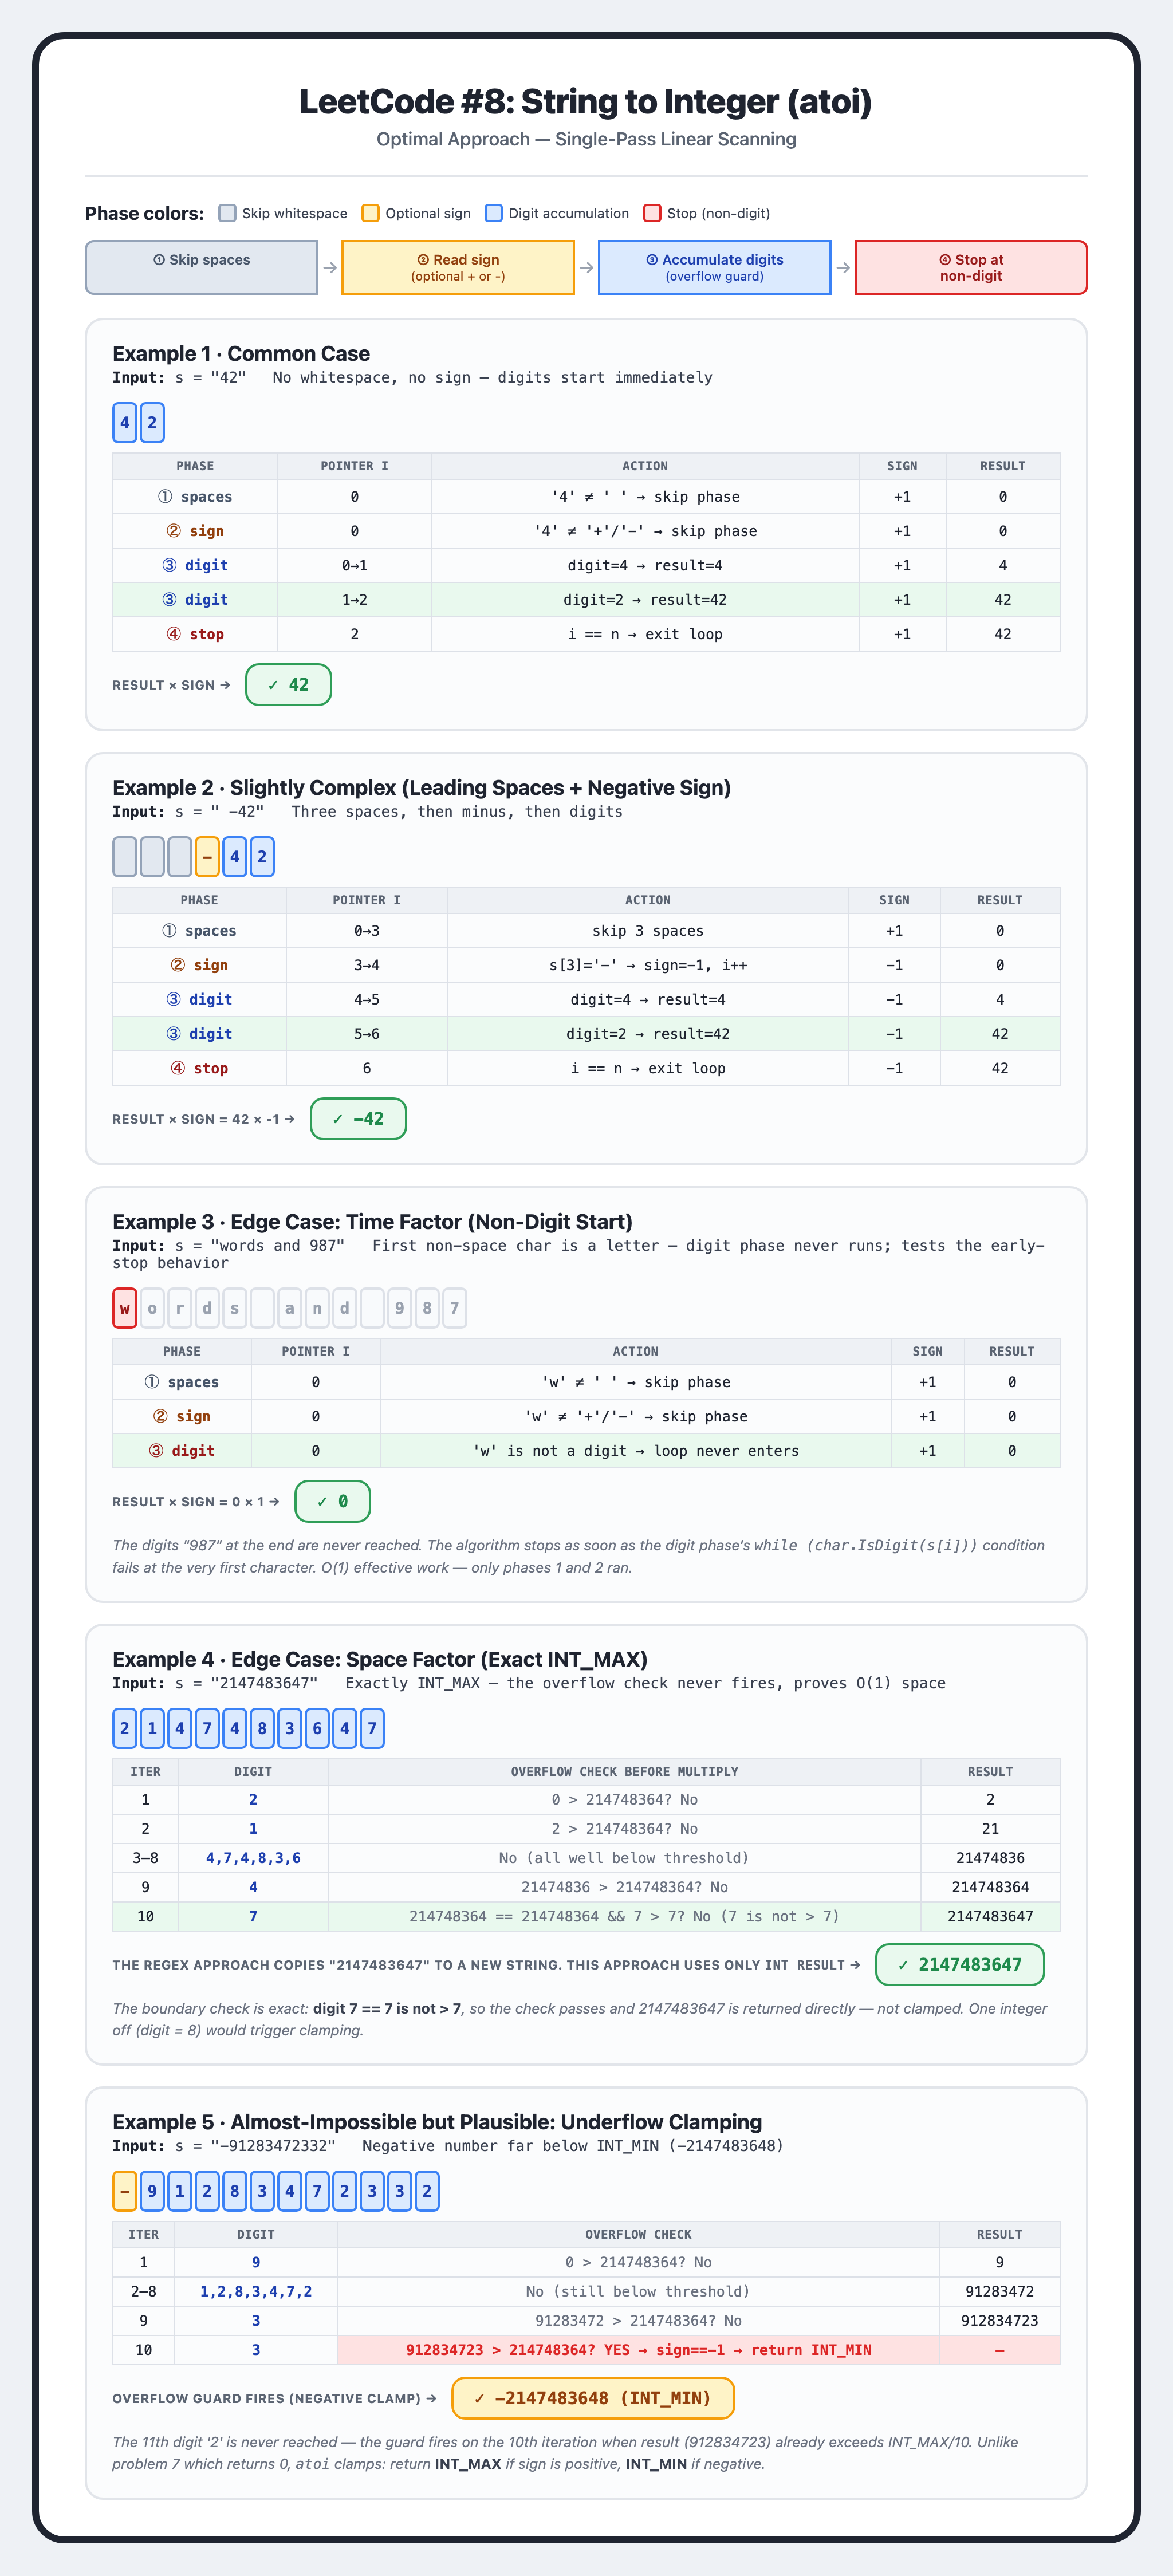